# Data Driven Models: Logistic Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression

print("packages imported")

packages imported


## Learning Goals

* Describe properties of the logistic function $\sigma(x;W,b)$
* Compute values of the least sqares and cross entropy cost functions
* Compute optimal parameters for logistic regression
* Use logistic regression models to make predictions

### Pre-Lecture Activities

- [Course notes](https://ubcmath.github.io/MATH360/data-driven/logistic-regression/index.html): Logistic Regression including the subsections on the Logistic Function and Cost and Regularization

## Clicker Questions

1. Suppose we have the logistic function $\sigma(x;W,0)$. Then as $W\to \infty$, the logistic function:

    A. Approaches the step function.
   
    B. Approaches the horizontal line $y=0$.
   
    C. Approaches the horizontal line $y=1$.
   
    D. Approaches the vertical line $x = 0$.

2. Suppose we have the logistic function $\sigma(x; W,b).$ The bias term, $b$, is a horizontal shift of the logistic function by $\dfrac{b}{W}$.

    A. True.

    B. False.

    C. Not Sure.

3. Regularization adds a penalty in to the calculation for the weights to penalize for large $W$ values.

    A. True.

    B. False.

    C. Not sure.

4. The goal of regularization is to:

    A. Control for large bias values.

    B. Ensure that the logistic function does not become a horizontal line.

    C. Ensure that the logistic function does not become a step function.

    D. Ensure there is a unique solution to the minimization problem.

    E. Both C and D. 

### A few notes about logistic regression

- Requires the output (or target) to have $2$ states.  These are typically $0$ or $1$. 
- We run a minimization procedure to determine the optimal weight $W$ and bias $b$ given the data.
    - We optimize a cost function in this case.
    - A cost function is a way to "measure" how "far away" a model is from the data.
    - Minimizing the cost means that we will be fitting the data better.
- There are a number of different types of cost functions, and some problems may have specific cost functions that are used.
- We will look at Least Squares ($\mathcal{L}^2$ norm) and Cross Entropy.
    - The idea behind least squares is to use Euclidean distance to "measure" how far the model is from the data.
    - The idea behind cross entropy is to "measure" the difference between the output data distribution and the output from the model distribution. (This is from Shannon's Entropy, which is outside the scope of Math 360).
- The optimal solution from the cost function is generally one with large $W$ values.  To help ensure that the weights are not too large, we introduce regularization.
    - This adds a penalty term of the form $\alpha |W|^2$.  So as $W \to \infty$, the penalty term  $\alpha |W|^2 \to \infty$ and the cost function also goes to infinity, which results in a non-optimal solution.   

## Logistic Regression Models for Real Estate Classification

The data below was taken from [REALTOR.ca](https://www.realtor.ca) for properties in the Kitsilano neighborhood of Vancouver. The vector of listing prices is measured in millions of dollars. Logistic regression expects the target variable to have values 0 or 1. Define a new variable $y$ such that $y=0$ if the property has 1 bedroom and $y = 1$ if the property has 2 bedrooms. Let $x$ be the listing price and plot $x$ versus $y$.

In [2]:
prices = [0.499,0.549,0.565,0.579,0.619,0.625,0.638,0.695,0.729,0.749,0.749,0.789,0.799,0.825,0.848,0.850,0.885,0.895,0.925,0.998,1.055,1.08]
bedrooms = [1,1,1,1,1,1,1,1,2,1,2,1,2,2,1,2,2,2,2,2,2,2]

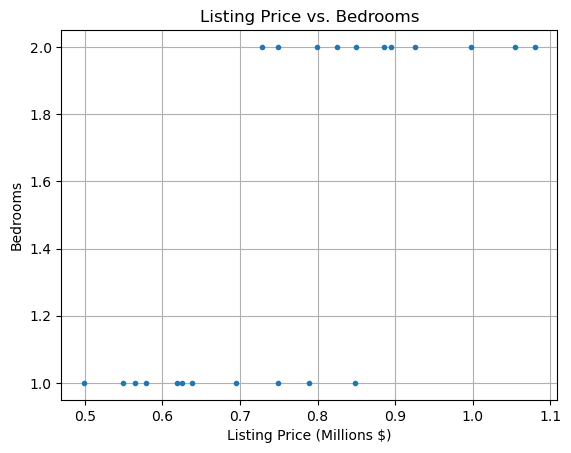

In [3]:
plt.plot(prices,bedrooms,'.')
plt.grid(True)
plt.title('Listing Price vs. Bedrooms')
plt.xlabel('Listing Price (Millions $)')
plt.ylabel('Bedrooms')
plt.show()

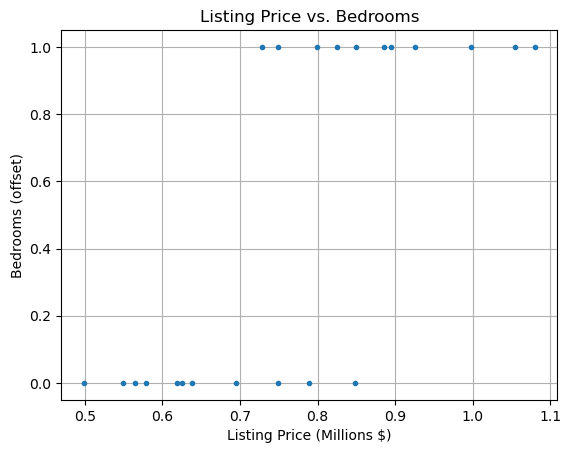

In [4]:
## redefine y to have one bedroom as y=0 and two bedroom as y=1
x = np.array(prices)
y = np.array(bedrooms) - 1
plt.plot(x,y,'.')
plt.grid(True)
plt.title('Listing Price vs. Bedrooms')
plt.xlabel('Listing Price (Millions $)')
plt.ylabel('Bedrooms (offset)')
plt.show()

Choose values $W$ and $b$ and plot the logistic function $\sigma(x;W,b)$. Use trial and error to find values $W$ and $b$ such that the logistic function fits the data.

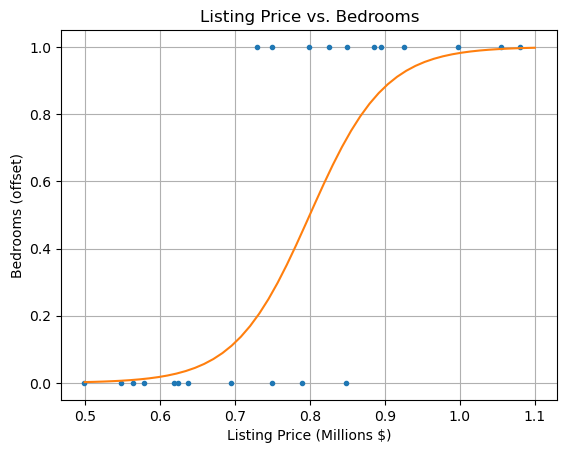

In [5]:
sigma = lambda x,W,b: 1/(1 + np.exp(-(W*x + b)))

xs = np.linspace(0.5,1.1,50)
ys = sigma(xs,20,-16)
plt.plot(x,y,'.')
plt.plot(xs,ys)
plt.grid(True)
plt.title('Listing Price vs. Bedrooms')
plt.xlabel('Listing Price (Millions $)')
plt.ylabel('Bedrooms (offset)')
plt.show()

Compute the least squares cost $C_{LS}$ for the values $W$ and $b$ found in the previous step. Use trial and error to modify the values $W$ and $b$ to minimise $C_{LS}$. Plot the corresponding logistic function.

W = 20 , b = -15 , Cost = 0.10528157188868893


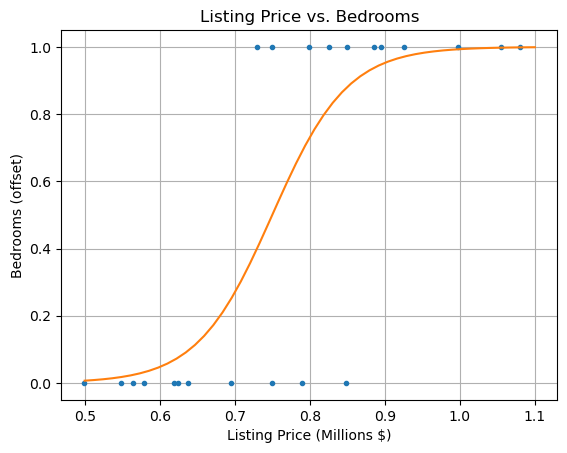

In [6]:
costLS = lambda W,b,x,y: 1/len(x)*np.sum((y - sigma(x,W,b))**2)


W1 = 20
b1 = -15
C = costLS(W1,b1,x,y)
print('W =',W1,', b =',b1,', Cost =',C)

xs = np.linspace(0.5,1.1,50)
ys = sigma(xs,W1,b1)
plt.plot(x,y,'.')
plt.plot(xs,ys)
plt.grid(True)
plt.title('Listing Price vs. Bedrooms')
plt.xlabel('Listing Price (Millions $)')
plt.ylabel('Bedrooms (offset)')
plt.show()

Use `scipy.optimize.minimize` to compute the optimal parameters $W$ and $b$ using the least squares cost function without regularization. Compare to the values $W$ and $b$ that you found in the previous steps.

In [7]:
## define a new variable z, which has two entries:
## z[0] = W, and z[1] = b
## then define a new function which takes in the data points x and y
## and the unknown z[0], z[1]
F = lambda z: costLS(z[0],z[1],x,y)

## run minimization
minimize(F,[20,-15]) ## here [20,-15] is the starting point for the minimization

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.10354111036241663
        x: [ 1.637e+01 -1.245e+01]
      nit: 16
      jac: [ 8.000e-07  1.170e-06]
 hess_inv: [[ 4.222e+03 -3.188e+03]
            [-3.188e+03  2.432e+03]]
     nfev: 60
     njev: 20

The output message here tells us some information:
- `success` will tells us whether the minimization was successful or not.  True indicates that it was successful
- `fun` will tell us the value of `F` at the minimum.  In our case, this is the value of the least-squares cost function
- `x` will tell us what the optimal values are.  The first entry corresponds to `z[0]` and the second entry corresponds to `z[1]`

In [8]:
## let's call the minimization in a slightly different way so that we 
## can print the W and b directly
result = minimize(F,[20,-15])
W2,b2 = result.x
print('W =',W2,', b =',b2)

W = 16.370636220900053 , b = -12.452701403196954


Use `scipy.optimize.minimize` to compute the optimal parameters $W$ and $b$ using the cross entropy cost function without regularization. Compare to the values $W$ and $b$ that you found in the previous steps.

In [9]:
## we will run the same minimization scheme, however, we will now swap the least-squares
## cost function with the cross entropy cost function

costCE = lambda W,b,x,y: -1/len(y)*np.sum(y*np.log(sigma(x,W,b)) + (1 - y)*np.log(1 - sigma(x,W,b)))

F = lambda z: costCE(z[0],z[1],x,y)
result = minimize(F,[20,-15])
W3,b3 = result.x
print('W =',W3,', b =',b3)

W = 20.58724026686891 , b = -15.816745255705506


Plot the logistic functions for the different values $W$ and $b$ found using $C_{LS}$ and $C_{CE}$. Is there much of a difference? Is it possible to describe how $C_{LS}$ and $C_{CE}$ measure error differently?

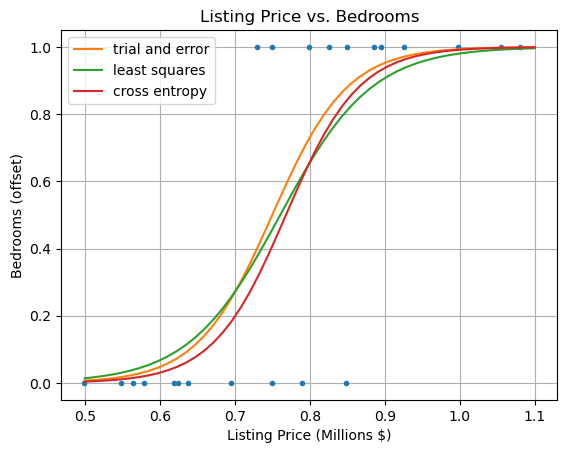

In [10]:
plt.plot(x,y,'.')
plt.plot(xs,sigma(xs,W1,b1),label='trial and error')
plt.plot(xs,sigma(xs,W2,b2),label='least squares')
plt.plot(xs,sigma(xs,W3,b3),label='cross entropy')
plt.grid(True)
plt.title('Listing Price vs. Bedrooms')
plt.xlabel('Listing Price (Millions $)')
plt.ylabel('Bedrooms (offset)')
plt.legend()
plt.show()

Use `scipy.optimize.minimize` to compute the optimal parameters $W$ and $b$ using the cross entropy cost function with L2 regularization for $\alpha=0.0,0.0001,0.001,0.01$. Plot the logistic function for each $\alpha$. What happens as $\alpha$ increases? Is L2 regularization improving the model?

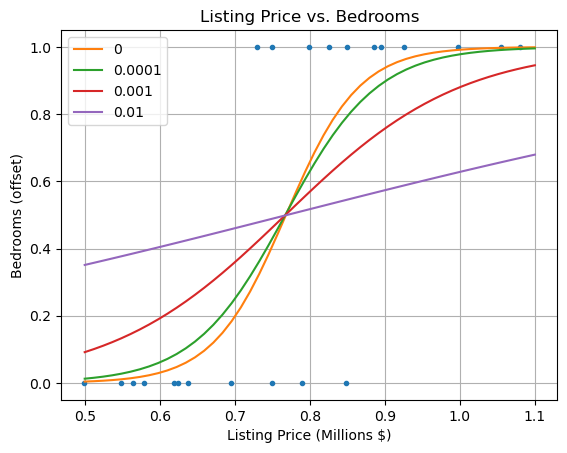

In [11]:
costCEL2 = lambda W,b,x,y,alpha: -1/len(y)*np.sum(y*np.log(sigma(x,W,b)) + (1 - y)*np.log(1 - sigma(x,W,b))) + alpha*np.abs(W)**2

xs = np.linspace(0.5,1.1,50)
plt.plot(x,y,'.')
for alpha in [0,0.0001,0.001,0.01]:
    F = lambda z: costCEL2(z[0],z[1],x,y,alpha)
    result = minimize(F,[20,-15])
    W,b = result.x
    plt.plot(xs,sigma(xs,W,b),label=alpha)
plt.grid(True)
plt.title('Listing Price vs. Bedrooms')
plt.xlabel('Listing Price (Millions $)')
plt.ylabel('Bedrooms (offset)')
plt.legend()
plt.show()

As $\alpha$ increases, we see the flattening out of the logistic curve. Does this improve the model?  Why might we want to include regularization in our numerical schemes?

The code below uses `sklearn.linear_model.LogisticRegression` to compute optimal parameters $W$ and $b$ for logistic regression. The result does not match any of our explicit calculations above. What is going on? Read the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) to figure out how to use `sklearn` to reproduce the results above.

In [12]:
model = LogisticRegression().fit(x.reshape((len(x),1)),y)
W = model.coef_[0,0]
b = model.intercept_[0]
print('W =',W,', b =',b)

W = 1.1542782129239142 , b = -0.8889606183595905


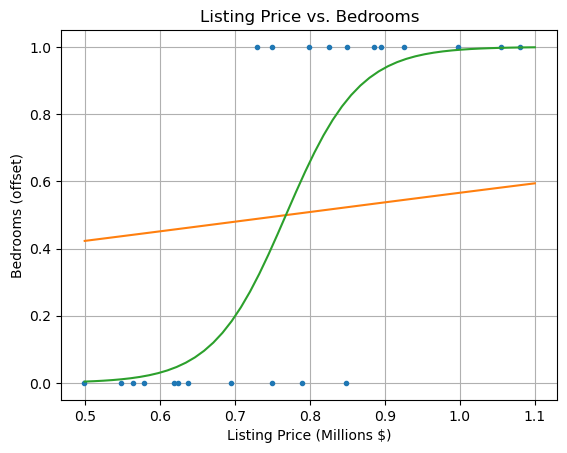

In [13]:
xs = np.linspace(0.5,1.1,50)
plt.plot(x,y,'.')
plt.plot(xs,sigma(xs,W,b))
W = 20.58256332
b = -15.81311152
plt.plot(xs,sigma(xs,W,b))
plt.grid(True)
plt.title('Listing Price vs. Bedrooms')
plt.xlabel('Listing Price (Millions $)')
plt.ylabel('Bedrooms (offset)')
plt.show()

**Remark:** This is not producing the correct result.  Why not?  Be sure to read through the the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) so that you are comfortable with using `sklearn` to reproduce the results above.   In this case, the default penalty applied is the `l2` penalty for the `LogisticRegression` package.  To obtain our desired result, we need to set the penalty to `None`.)

W = 20.590227344545248 , b = -15.81815272015315


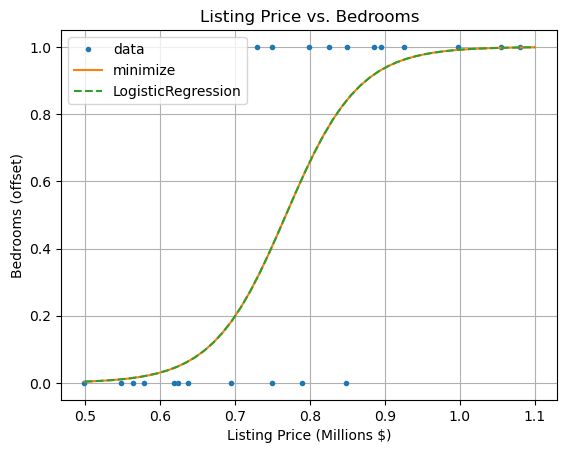

In [16]:
model = LogisticRegression(penalty=None).fit(x.reshape((len(x),1)),y)
W = model.coef_[0,0]
b = model.intercept_[0]
print('W =',W,', b =',b)

xs = np.linspace(0.5,1.1,50)
plt.plot(x,y,'.',label = 'data')
plt.plot(xs,sigma(xs,W,b),label = 'minimize')
W = 20.590227344545248
b = -15.81815272015315
plt.plot(xs,sigma(xs,W,b),linestyle = 'dashed',label = 'LogisticRegression')
plt.grid(True)
plt.legend()
plt.title('Listing Price vs. Bedrooms')
plt.xlabel('Listing Price (Millions $)')
plt.ylabel('Bedrooms (offset)')
plt.show()

Notice how `LogisticRegression` now gives the same answer as the one we found by manually doing the minimization process throught he `minimize` function. 

To add regularization in to the `LogisticRegression` function, we need to set the `C` value.  The $C$ values is the **inverse of the regularization value**.  This means that we need to set $C = \dfrac{1}{\alpha}.$  Let's plot the logistic function for a regularization value of $\alpha = \dfrac{1}{1000} \implies C = 1000.$

W = 19.2017496501092 , b = -14.745930266526601


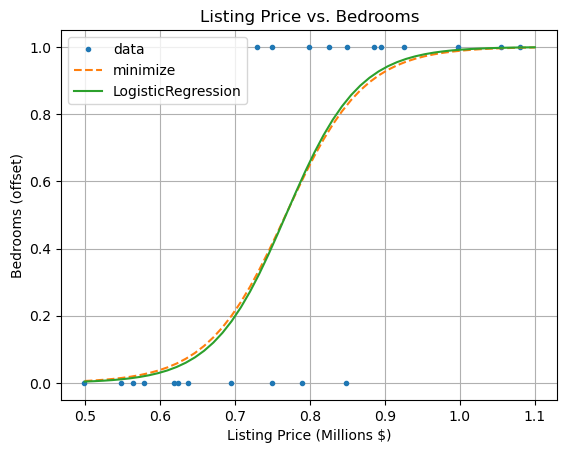

In [15]:
model = LogisticRegression(C=1000).fit(x.reshape((len(x),1)),y)
W = model.coef_[0,0]
b = model.intercept_[0]
print('W =',W,', b =',b)

xs = np.linspace(0.5,1.1,50)
plt.plot(x,y,'.',label = 'data')
plt.plot(xs,sigma(xs,W,b),label = 'minimize')
W = 20.590227344545248
b = -15.81815272015315
plt.plot(xs,sigma(xs,W,b),linestyle = 'dashed',label = 'LogisticRegression')
plt.grid(True)
plt.legend()
plt.title('Listing Price vs. Bedrooms')
plt.xlabel('Listing Price (Millions $)')
plt.ylabel('Bedrooms (offset)')
plt.show()


Notice that the $W$ value has decreased with the regularization, which is expected, since we are now penalizing for large $W$ values. Notice how the regularized curve is also fairly similar to the curve we achieved from the `minimize` function without regularization.

Construct the logistic regression model that you think best suits the data. Use the logistic regression model to find the listing price $P$ for which the model predicts a 2 bedroom property with 90% confidence.